## Tree-Based Models

In this notebook, we compare four tree-based regression models to predict rate_avg (average Airbnb listing price), including a decision tree, bagging, random forest, and gradient boosting.

We start with a single decision tree as a baseline, then move to ensemble methods to reduce overfitting and improve performance. For each model, we evaluate MSE, RMSE, MAE, MAPE, and R², and perform hyperparameter tuning where appropriate.

At the end, we also explore feature importance using random forest to see whether reducing the number of features affects model performance.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor


In [10]:
df = pd.read_csv("Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3225, 71)


,rate_avg,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days,avg_temp
0,36.3,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,-3.925
1,35.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,0.770
2,35.9,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,7.040
3,36.0,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,13.890
4,36.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,19.470


In [11]:
X = df.drop(columns=["rate_avg"])
y = df["rate_avg"]


We split the dataset into training and test sets using an 80/20 split. With 3,225 total observations, this gives us 2,580 training samples and 645 for testing.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2580, 70) (645, 70) (2580,) (645,)


### Decision Tree (Baseline)

We start with an untuned decision tree as our baseline. Without any depth limit, the tree can grow very large and closely fit the training data, which can lead to overfitting.

The baseline model achieves an RMSE of 25.95 and an R² of 0.937 on the test set. While this seems reasonably good, the MAPE of 9.5% shows that predictions are still off by about 10% on average.

This baseline gives us a reference point and indicates a need for hyperparameter tuning and ensemble methods to improve performance

In [13]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_mse  = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_mae  = mean_absolute_error(y_test, y_pred_dt)
dt_mape = mean_absolute_percentage_error(y_test, y_pred_dt)
dt_r2   = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MSE: ", dt_mse)
print("RMSE:", dt_rmse)
print("MAE: ", dt_mae)
print("MAPE:", dt_mape)
print("R²:  ", dt_r2)


Decision Tree Results
MSE:  673.4934263565891
RMSE: 25.951751893785303
MAE:  12.654883720930233
MAPE: 0.09514852231576398
R²:   0.9367080625666092


### Hyperparameter Tuning - Decision Tree

max_depth controls how far the tree is allowed to split. If the tree is too shallow, it may miss patterns in the data, while a very deep tree can overfit the training data.

We test depths from 1 to 30 and track both training and test MSE. The best depth was 20, which reduced test MSE from 673.5 to 591.5.

In [14]:
dt_depth_mse = {'k': [], 'train_mse': [], 'test_mse': []}

for k in range(1, 31):
    print("Fit with max_depth:", k, end='\r', flush=True)

    model = DecisionTreeRegressor(max_depth=k, random_state=42)
    model.fit(X_train, y_train)

    preds_train = model.predict(X_train)
    preds_test = model.predict(X_test)

    dt_depth_mse['k'].append(k)
    dt_depth_mse['train_mse'].append(mean_squared_error(y_train, preds_train))
    dt_depth_mse['test_mse'].append(mean_squared_error(y_test, preds_test))

# Find the depth with the minimum test MSE
best_idx = dt_depth_mse['test_mse'].index(min(dt_depth_mse['test_mse']))
best_depth = dt_depth_mse['k'][best_idx]

print("\nDepth of the model yielding minimum test MSE is:", best_depth)
print("Minimum test MSE:", min(dt_depth_mse['test_mse']))

Fit with max_depth: 30
Depth of the model yielding minimum test MSE is: 20
Minimum test MSE: 591.4991335319656


### Training vs Test MSE by Tree Depth

This plot shows how model performance changes as tree depth increases. Training MSE decreases steadily, while test MSE improves up to around depth 20 and then levels off (with slight increases). This indicates overfitting.

The gap between the two curves becomes noticeable as depth increases and is larger after depth 20, which supports our choice of using this value as a reasonable depth for the decision tree.

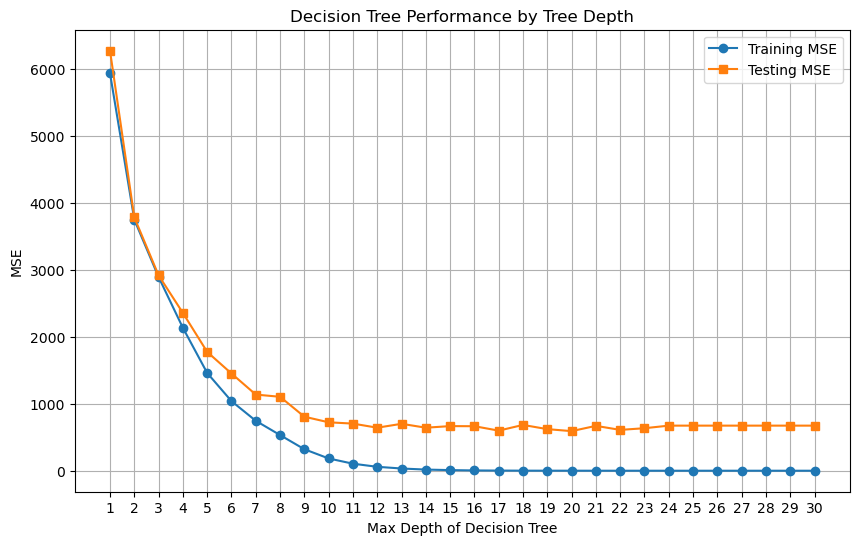

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(dt_depth_mse['k'], dt_depth_mse['train_mse'], label='Training MSE', marker='o')
plt.plot(dt_depth_mse['k'], dt_depth_mse['test_mse'], label='Testing MSE', marker='s')
plt.title('Decision Tree Performance by Tree Depth')
plt.xlabel('Max Depth of Decision Tree')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.xticks(dt_depth_mse['k'])
plt.show()

In [16]:
best_dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_dt.fit(X_train, y_train)

y_pred_dt_tuned = best_dt.predict(X_test)

dt_tuned_mse  = mean_squared_error(y_test, y_pred_dt_tuned)
dt_tuned_rmse = np.sqrt(dt_tuned_mse)
dt_tuned_mae  = mean_absolute_error(y_test, y_pred_dt_tuned)
dt_tuned_mape = mean_absolute_percentage_error(y_test, y_pred_dt_tuned)
dt_tuned_r2   = r2_score(y_test, y_pred_dt_tuned)

print("Tuned Decision Tree Results")
print("MSE: ", dt_tuned_mse)
print("RMSE:", dt_tuned_rmse)
print("MAE: ", dt_tuned_mae)
print("MAPE:", dt_tuned_mape)
print("R²:  ", dt_tuned_r2)


Tuned Decision Tree Results
MSE:  591.4991335319656
RMSE: 24.32075520069156
MAE:  11.691070505721669
MAPE: 0.08902728998556397
R²:   0.9444135240429377


In [17]:
bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)

bagging_mse  = mean_squared_error(y_test, y_pred_bagging)
bagging_rmse = np.sqrt(bagging_mse)
bagging_mae  = mean_absolute_error(y_test, y_pred_bagging)
bagging_mape = mean_absolute_percentage_error(y_test, y_pred_bagging)
bagging_r2   = r2_score(y_test, y_pred_bagging)

print("Bagging Regressor Results")
print("MSE: ", bagging_mse)
print("RMSE:", bagging_rmse)
print("MAE: ", bagging_mae)
print("MAPE:", bagging_mape)
print("R²:  ", bagging_r2)


Bagging Regressor Results
MSE:  438.39055945775203
RMSE: 20.9377782837089
MAE:  10.778205426356594
MAPE: 0.08163540349370849
R²:   0.9588019915640595


### Bagging Results in Context

The bagging method trains multiple decision trees on different samples of the training data and averages their predictions. Averaging many trees helps reduce variance compared to a single decision tree. Here, we use 200 trees, each trained on 80% of the training data.

Switching to bagging (200 trees trained on 80% of the data with replacement) improves performance compared to the single decision tree. RMSE decreases to 20.94 (from 24.32 with the tuned tree), and MAPE drops to 8.2%, meaning predictions are off by about 8% on average.

The R² of 0.959 shows that the model explains more variance in listing price than the single tree. This improvement is due to averaging across multiple trees, which helps reduce variance.

### Random Forest Regressor (Baseline)

The baseline random forest (100 trees with default settings) performs slightly better than the bagging model, with an RMSE of 20.16 and MAPE of 7.8%.

The main difference from bagging is that at each split, only a random subset of features is considered instead of all features. This makes the trees less similar to each other, which improves the effect of averaging. Even without tuning, the random forest performs well, suggesting that feature subsampling is improving model performance on this dataset.

In [18]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mse  = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_mape = mean_absolute_percentage_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MSE: ", rf_mse)
print("RMSE:", rf_rmse)
print("MAE: ", rf_mae)
print("MAPE:", rf_mape)
print("R²:  ", rf_r2)


Random Forest Results
MSE:  406.50303557829494
RMSE: 20.161920433785443
MAE:  10.321029457364345
MAPE: 0.07836265614916832
R²:   0.961798640213182


### Hyperparameter Tuning - Random Forest

Instead of considering all features at each split, random forest will look only at a random subset of features. So, we run a grid search over max_depth (5 to 30) and n_estimators (50 to 250) using 5-fold cross-validation with MAE as the scoring metric. The search evaluated 30 parameter combinations across 150 total fits.

The best combination found was max_depth = 25 and n_estimators = 250, both at the upper end of the search range. This suggests that increasing model complexity can slightly improve performance. However, the improvement over the baseline random forest is small.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize base random forest model
rf_clf = RandomForestRegressor(random_state=42)

# Define parameter grid
rf_params = {
    'max_depth': np.arange(5, 31, 5),
    'n_estimators': np.arange(50, 251, 50)
}

# Grid search
rf_grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=rf_params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)

rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': array([ 5, 10..., 20, 25, 30]), 'n_estimators': array([ 50, 1...50, 200, 250])}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,np.int64(250)


In [20]:
print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

Best Random Forest parameters:
{'max_depth': np.int64(25), 'n_estimators': np.int64(250)}


In [21]:
best_rf = rf_grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

rf_tuned_mse  = mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)
rf_tuned_mae  = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_mape = mean_absolute_percentage_error(y_test, y_pred_rf_tuned)
rf_tuned_r2   = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Results")
print("MSE: ", rf_tuned_mse)
print("RMSE:", rf_tuned_rmse)
print("MAE: ", rf_tuned_mae)
print("MAPE:", rf_tuned_mape)
print("R²:  ", rf_tuned_r2)


Tuned Random Forest Results
MSE:  407.4236618625653
RMSE: 20.184738340205584
MAE:  10.305597575595707
MAPE: 0.07781380421457706
R²:   0.9617121238213312


### Cross-Validation

A single train/test split can be unreliable since results depend on how the data is divided. For a more reliable estimate, we can use a 5-fold cross-validation to rotate which 20% of the data is used for testing.

The results show a clear difference: the cross-validated RMSE for the decision tree is 69.9, compared to 51.1 for bagging and 51.5 for random forest. This indicates that the ensemble models are not only performing better on a single split, but are also more consistent across different subsets of the data.

In [22]:
dt_cv = cross_val_score(
    DecisionTreeRegressor(random_state=42),
    X, y,
    cv=5,
    scoring="neg_mean_squared_error"
)

bagging_cv = cross_val_score(
    BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=200,
        max_samples=0.8,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),
    X, y,
    cv=5,
    scoring="neg_mean_squared_error"
)

rf_cv = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X, y,
    cv=5,
    scoring="neg_mean_squared_error"
)

print("Decision Tree CV RMSE:", np.mean(np.sqrt(-dt_cv)))
print("Bagging CV RMSE:", np.mean(np.sqrt(-bagging_cv)))
print("Random Forest CV RMSE:", np.mean(np.sqrt(-rf_cv)))

Decision Tree CV RMSE: 69.89929077584799
Bagging CV RMSE: 51.063690821551546
Random Forest CV RMSE: 51.535643442309116


### Feature Importance

The tuned random forest highlights the most important features. 'guests' accounts for 51.7% of total importance, followed by 'bedrooms' at 17.8%.

After that, features such as 'min_nights', 'cleaning_fee', 'longitude', and 'latitude' contribute to the model, but the remaining features each have relatively low importance.

This concentration among a few top features suggests that many variables contribute little to prediction, and this emphasizes the importance of our feature selection (done in later steps).

In [23]:
feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

guests                    0.517196
bedrooms                  0.178137
min_nights                0.053256
cleaning_fee              0.043009
longitude                 0.023405
latitude                  0.021397
num_reviews               0.017810
room_type_private_room    0.015899
rating_overall            0.014414
photos_count              0.012637
dtype: float64


## Gradient Boosting 
#### What is Gradient Boosting? 
Gradient Boosting is an ensemble machine learning method that builds many sequential predictive models to minimize error with every new tree. In simple terms, every sequential tree focuses on fixing the mistakes made by the previous ones. Rather than training trees independently like the random forest model used above, it works in sequential stages and gradually aims to improve upon previous models by minimizing errors at each step. We included Gradient Boosting in our analysis because of its strong predictive performance on structured datasets and its ability to better tune hyperparameters, such as learning_rate, n_estimators, and max_depth, which allow us to control model complexity when predicting rate_avg.

#### Gradient Boosting vs. Random Forest

Gradient Boosting and Random Forest are both ensemble methods that combine multiple decision trees but they do have key differences in how they are built. Random Forest trains trees independently on random subsets of the data and averages their predictions, which reduces overfitting. Gradient Boosting instead builds trees sequentially, where each new tree focuses on correcting the errors of the previous ones, making it more sensitive to patterns in the data but also more likely to overfit.


### Baseline Gradient Boosting Model

Gradient boosting builds trees sequentially, with each new tree focusing on the errors made by the earlier ones. This can produce stronger predictive performance than bagging-style methods when the tuning is appropriate.

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_features=5,
    max_depth=5,
    random_state=42
)

model_gb.fit(X_train, y_train)

preds_gb = model_gb.predict(X_test)

mse  = mean_squared_error(y_test, preds_gb)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, preds_gb)
mape = mean_absolute_percentage_error(y_test, preds_gb)
r2   = r2_score(y_test, preds_gb)

print("Gradient Boosting Results")
print("MSE: ", mse)
print("RMSE:", rmse)
print("MAE: ", mae)
print("MAPE:", mape)
print("R²:  ", r2)


Gradient Boosting Results
MSE:  951.0180432893592
RMSE: 30.838580435703573
MAE:  20.436149912036377
MAPE: 0.18961485198500136
R²:   0.910627524875014


### Hyperparameter Tuning

We use GridSearchCV to test several combinations of gradient boosting hyperparameters. The selected model is the combination that performs best under cross-validation within the search grid.   To optimize the Gradient Boosting model, we used GridSearchCV with 5-fold cross-validation, searching over max_depth, n_estimators, and learning_rate. The search was scored using negative mean absolute error to identify the combination that minimized prediction error across folds. The best parameters found were then used to refit the model and evaluate it on the test set.

In [25]:
gbr = GradientBoostingRegressor(random_state=156)
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': np.arange(5, 30, 5),
    'n_estimators': np.arange(50, 210, 50),
    'learning_rate': np.arange(0.01, 0.31, 0.1)
}

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,GradientBoost...dom_state=156)
,param_grid,"{'learning_rate': array([0.01, 0.11, 0.21]), 'max_depth': array([ 5, 10, 15, 20, 25]), 'n_estimators': array([ 50, 100, 150, 200])}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,loss,'squared_error'


### Best Parameters

This output shows the hyperparameter combination selected by cross-validation for gradient boosting. Those values define the tuned model evaluated in the next section.

In [26]:
print("Best parameters found:", grid_search.best_params_)

Best parameters found: {'learning_rate': np.float64(0.11), 'max_depth': np.int64(10), 'n_estimators': np.int64(200)}


### Evaluate Best Model

Using the best estimator identified by GridSearchCV, we generate predictions on the test set and evaluate the tuned Gradient Boosting model using our standardized error metrics: MSE, RMSE, MAE, MAPE, and R². These metrics allow us to directly compare the tuned model's performance against both the baseline Gradient Boosting model and the other models in our analysis.

In [27]:
clf_best = grid_search.best_estimator_

y_test_pred = clf_best.predict(X_test)

gb_tuned_mse  = mean_squared_error(y_test, y_test_pred)
gb_tuned_rmse = np.sqrt(gb_tuned_mse)
gb_tuned_mae  = mean_absolute_error(y_test, y_test_pred)
gb_tuned_mape = mean_absolute_percentage_error(y_test, y_test_pred)
gb_tuned_r2   = r2_score(y_test, y_test_pred)

print("Tuned Gradient Boosting Results")
print("MSE: ", gb_tuned_mse)
print("RMSE:", gb_tuned_rmse)
print("MAE: ", gb_tuned_mae)
print("MAPE:", gb_tuned_mape)
print("R²:  ", gb_tuned_r2)


Tuned Gradient Boosting Results
MSE:  439.4932503036949
RMSE: 20.964094311553144
MAE:  9.873526781029211
MAPE: 0.0722522118389821
R²:   0.9586983655488698


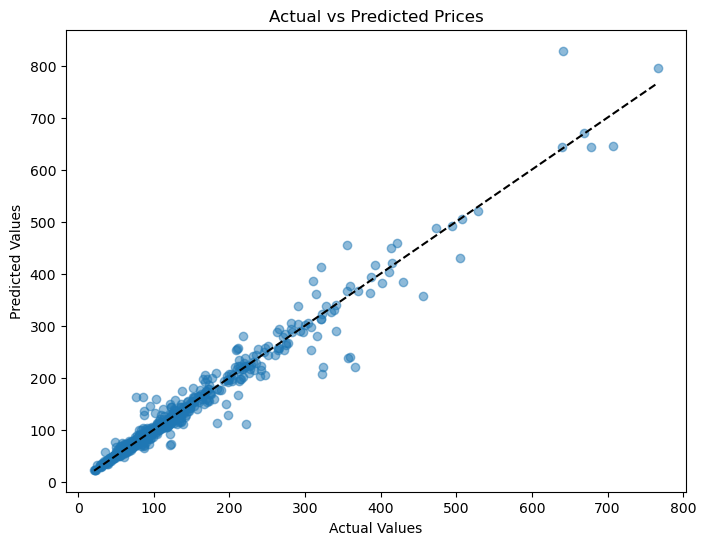

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Prices")
plt.show()

### Actual vs Predicted Plot (Gradient Boosting tuned)
This scatter plot compares the tuned Gradient Boosting model's predicted values against the actual rate_avg values on the test set. Points that fall close to the diagonal dashed line indicate accurate predictions. The overall clustering shows close alignment near the line, this suggests the model captures the general pricing trend well, although there are still some spread at higher price values indicates the model has more difficulty predicting outlier listings accurately.


In [29]:
results = pd.DataFrame(
    [
        {
            "Model": "Decision Tree (baseline)",
            "MSE":  round(mean_squared_error(y_test, y_pred_dt), 4),
            "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 4),
            "MAE":  round(mean_absolute_error(y_test, y_pred_dt), 4),
            "MAPE": round(mean_absolute_percentage_error(y_test, y_pred_dt), 4),
            "R²":   round(r2_score(y_test, y_pred_dt), 6),
        },
        {
            "Model": "Decision Tree (tuned)",
            "MSE":  dt_tuned_mse,  "RMSE": dt_tuned_rmse,
            "MAE":  dt_tuned_mae,  "MAPE": dt_tuned_mape,  "R²": dt_tuned_r2,
        },
        {
            "Model": "Bagging Regressor",
            "MSE":  bagging_mse,  "RMSE": bagging_rmse,
            "MAE":  bagging_mae,  "MAPE": bagging_mape,  "R²": bagging_r2,
        },
        {
            "Model": "Random Forest (baseline)",
            "MSE":  rf_mse,  "RMSE": rf_rmse,
            "MAE":  rf_mae,  "MAPE": rf_mape,  "R²": rf_r2,
        },
        {
            "Model": "Random Forest (tuned)",
            "MSE":  rf_tuned_mse,  "RMSE": rf_tuned_rmse,
            "MAE":  rf_tuned_mae,  "MAPE": rf_tuned_mape,  "R²": rf_tuned_r2,
        },
        {
            "Model": "Gradient Boosting (baseline)",
            "MSE":  round(mse, 4),  "RMSE": round(rmse, 4),
            "MAE":  round(mae, 4),  "MAPE": round(mape, 4),  "R²": round(r2, 6),
        },
        {
            "Model": "Gradient Boosting (tuned)",
            "MSE":  round(gb_tuned_mse, 4),  "RMSE": round(gb_tuned_rmse, 4),
            "MAE":  round(gb_tuned_mae, 4),  "MAPE": round(gb_tuned_mape, 4),
            "R²":   round(gb_tuned_r2, 6),
        },
    ]
).sort_values("RMSE").reset_index(drop=True)

results


,Model,MSE,RMSE,MAE,MAPE,R²
0,Random Forest (baseline),406.503036,20.161920,10.321029,0.078363,0.961799
1,Random Forest (tuned),407.423662,20.184738,10.305598,0.077814,0.961712
2,Bagging Regressor,438.390559,20.937778,10.778205,0.081635,0.958802
3,Gradient Boosting (tuned),439.493300,20.964100,9.873500,0.072300,0.958698
4,Decision Tree (tuned),591.499134,24.320755,11.691071,0.089027,0.944414
5,Decision Tree (baseline),673.493400,25.951800,12.654900,0.095100,0.936708
6,Gradient Boosting (baseline),951.018000,30.838600,20.436100,0.189600,0.910628


### Overall Comparison 

The Random Forest models performed the best overall, with both the baseline and tuned versions having very similar RMSE values of 20.16 and 20.18 and an R² of around 0.962, meaning they explain over 96% of the variance in rate_avg. Tuning had little effect on the Random Forest, suggesting our baseline model was already a good fit for the data. The Bagging Regressor and tuned Gradient Boosting performed similarly with RMSE values just under 21, though the tuned Gradient Boosting achieved the lowest MAE of 9.87 and MAPE of 0.072, meaning its individual predictions were on average more accurate even if its overall squared error was slightly higher. The Decision Tree models were the weakest performers as expected, with the baseline version producing an RMSE of 25.95 and R² of 0.937, which makes sense because a single unpruned tree tends to overfit. The Gradient Boosting baseline was the worst overall with an RMSE of 30.84 and MAPE of around 0.19, showing how much hyperparameter tuning matters for the Gradient Boosting model  compared to the other models as it showed significant improvement with tuning.

## Feature Selection

We use the feature importances from the tuned Random Forest to drop low-signal features,
then retrain all models on the reduced feature set and compare metrics against the original results.

### Step 1: Identify low-importance features

Plot the full importance distribution and choose a threshold. Features below the threshold
contribute little signal and may add noise.

Total features: 70
Features with importance < 0.005: 56
Features with importance < 0.001: 38


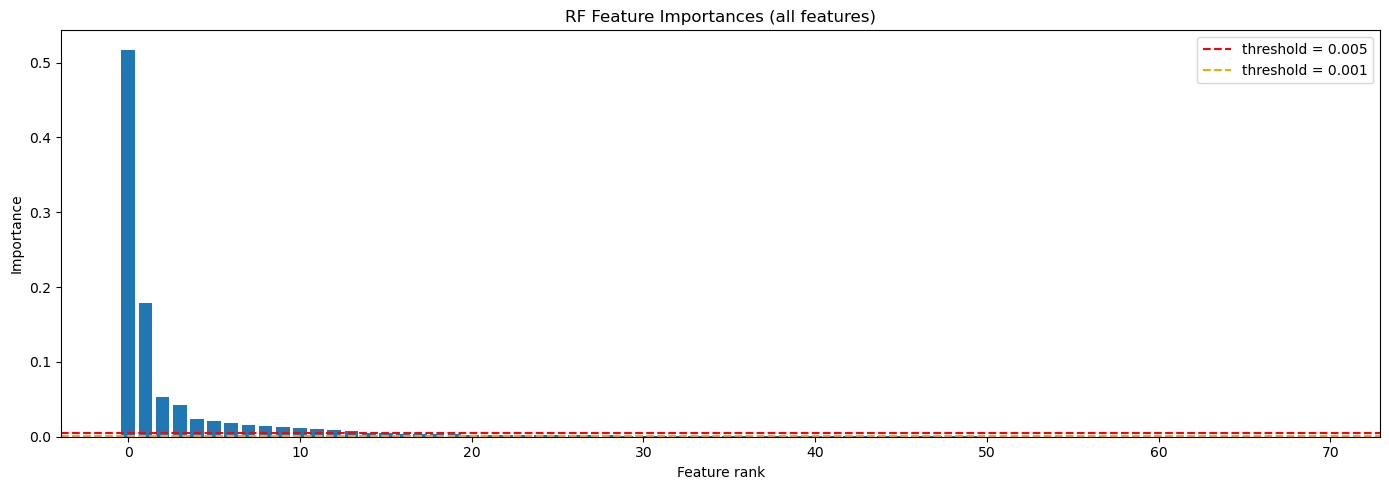

In [30]:

feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(f"Total features: {len(feature_importance)}")
print(f"Features with importance < 0.005: {(feature_importance < 0.005).sum()}")
print(f"Features with importance < 0.001: {(feature_importance < 0.001).sum()}")

# Plot distribution
plt.figure(figsize=(14, 5))
plt.bar(range(len(feature_importance)), feature_importance.values)
plt.axhline(y=0.005, color="red", linestyle="--", label="threshold = 0.005")
plt.axhline(y=0.001, color="orange", linestyle="--", label="threshold = 0.001")
plt.xlabel("Feature rank")
plt.ylabel("Importance")
plt.title("RF Feature Importances (all features)")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance Plot: 
The feature importance plot shows the relative contribution of each predictor to the tuned Random Forest's predictions. guests is by far the most important feature with an importance score of 0.52, followed by bedrooms at 0.18. Together these two features account for nearly 70% of the model's predictions, which makes sense intuitively as a properties capacity is a primary driver of Airbnb pricing. Most of the remaining features contribute very little which motivated us to try a feature selction method to see how this could improve our model further. 

### Step 2: Apply threshold and build reduced feature set

We keep only features above the 0.005 importance threshold. This removes features
that contribute negligible signal while preserving the predictive core of the model.

In [31]:
THRESHOLD = 0.005

selected_features = feature_importance[feature_importance >= THRESHOLD].index.tolist()
dropped_features = feature_importance[feature_importance < THRESHOLD].index.tolist()

print(f"Features kept:   {len(selected_features)}")
print(f"Features dropped: {len(dropped_features)}")
print(f"Dropped features:")
print(dropped_features)

Features kept:   14
Features dropped: 56
Dropped features:
['non_resident_visitors', 'listing_type_Entire condo', 'avg_temp', 'cancellation_policy_Strict', 'Hotel_Occupancy_Percentage', 'rating_value', 'Average_Daily_Rate', 'has_gym', 'Revenue_Per_Available_Room', 'rating_checkin', 'cancellation_policy_Limited', 'rating_cleanliness', 'rating_communication', 'listing_type_Private room in home', 'rating_accuracy', 'extra_guest_fee', 'listing_type_Entire rental unit', 'superhost', 'is_fall', 'cancellation_policy_Flexible', 'has_pool', 'cancellation_policy_Moderate', 'has_free_parking', 'num_major_events', 'listing_type_Entire loft', 'is_summer', 'is_march', 'is_spring', 'num_public_holidays', 'is_november', 'listing_type_Entire home', 'is_may', 'is_june', 'is_april', 'listing_type_Entire condominium', 'is_july', 'is_october', 'is_winter', 'is_september', 'is_february', 'is_august', 'listing_type_Private room in rental unit', 'listing_type_Entire guest suite', 'listing_type_Private room in

### Results of Applying Threshold
Based on the importance distribution, we applied a threshold of 0.005 to identify features contributing little to the model. This resulted in keeping 14 features and dropping 56, including most of the listing type, seasonal, and cancellation policy variables that had very little impact on predictions.

In [32]:
# Build reduced train/test sets
X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

print("Reduced X_train shape:", X_train_sel.shape)
print("Reduced X_test shape: ", X_test_sel.shape)

Reduced X_train shape: (2580, 14)
Reduced X_test shape:  (645, 14)


### Step 3: Retrain all models on the reduced feature set

We retrain every model using the same hyperparameters as before so the only
change is the feature set. This lets us isolate the effect of feature selection.

In [33]:
# Decision Tree (baseline) 
dt_sel = DecisionTreeRegressor(random_state=42)
dt_sel.fit(X_train_sel, y_train)
y_pred_dt_sel = dt_sel.predict(X_test_sel)

# Decision Tree (tuned) 
dt_tuned_sel = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_tuned_sel.fit(X_train_sel, y_train)
y_pred_dt_tuned_sel = dt_tuned_sel.predict(X_test_sel)

# Bagging 
bagging_sel = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=200, max_samples=0.8, bootstrap=True,
    random_state=42, n_jobs=-1
)
bagging_sel.fit(X_train_sel, y_train)
y_pred_bagging_sel = bagging_sel.predict(X_test_sel)

# Random Forest (baseline) 
rf_sel = RandomForestRegressor(n_estimators=100, random_state=42)
rf_sel.fit(X_train_sel, y_train)
y_pred_rf_sel = rf_sel.predict(X_test_sel)

# Random Forest (tuned)
best_params_rf = rf_grid_search.best_params_
rf_tuned_sel = RandomForestRegressor(
    max_depth=int(best_params_rf["max_depth"]),
    n_estimators=int(best_params_rf["n_estimators"]),
    random_state=42
)
rf_tuned_sel.fit(X_train_sel, y_train)
y_pred_rf_tuned_sel = rf_tuned_sel.predict(X_test_sel)

# Gradient Boosting (baseline) 
gb_sel = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.01,
    max_features=5, max_depth=5, random_state=42
)
gb_sel.fit(X_train_sel, y_train)
y_pred_gb_sel = gb_sel.predict(X_test_sel)

# Gradient Boosting (tuned)
best_params_gb = grid_search.best_params_
gb_tuned_sel = GradientBoostingRegressor(
    learning_rate=float(best_params_gb["learning_rate"]),
    max_depth=int(best_params_gb["max_depth"]),
    n_estimators=int(best_params_gb["n_estimators"]),
    random_state=42
)
gb_tuned_sel.fit(X_train_sel, y_train)
y_pred_gb_tuned_sel = gb_tuned_sel.predict(X_test_sel)



### Step 4: Compare results : Original vs. Feature-selected

Side-by-side comparison of all the error metrics before and after feature selection.
Improvements suggest the dropped features were adding noise, regressions are unlikely
but would indicate some dropped features carried useful signal.

In [34]:
def metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return (round(mse, 4), round(np.sqrt(mse), 4),
            round(mae, 4), round(mape, 4), round(r2, 6))

rows = [
    ("Decision Tree (baseline)",    y_pred_dt,          y_pred_dt_sel),
    ("Decision Tree (tuned)",       y_pred_dt_tuned,    y_pred_dt_tuned_sel),
    ("Bagging Regressor",           y_pred_bagging,     y_pred_bagging_sel),
    ("Random Forest (baseline)",    y_pred_rf,          y_pred_rf_sel),
    ("Random Forest (tuned)",       y_pred_rf_tuned,    y_pred_rf_tuned_sel),
    ("Gradient Boosting (baseline)", preds_gb,          y_pred_gb_sel),
    ("Gradient Boosting (tuned)",   y_test_pred,        y_pred_gb_tuned_sel),
]

records = []
for name, orig_pred, sel_pred in rows:
    mse_o, rmse_o, mae_o, mape_o, r2_o = metrics(y_test, orig_pred)
    mse_s, rmse_s, mae_s, mape_s, r2_s = metrics(y_test, sel_pred)
    records.append({
        "Model":              name,
        "MSE (all feats)":   mse_o,   "MSE (selected)":   mse_s,   "ΔMSE":   round(mse_s  - mse_o,  4),
        "RMSE (all feats)":  rmse_o,  "RMSE (selected)":  rmse_s,  "ΔRMSE":  round(rmse_s - rmse_o, 4),
        "MAE (all feats)":   mae_o,   "MAE (selected)":   mae_s,   "ΔMAE":   round(mae_s  - mae_o,  4),
        "MAPE (all feats)":  mape_o,  "MAPE (selected)":  mape_s,  "ΔMAPE":  round(mape_s - mape_o, 4),
        "R² (all feats)":    r2_o,    "R² (selected)":    r2_s,    "ΔR²":    round(r2_s   - r2_o,   6),
    })

comparison = pd.DataFrame(records).sort_values("RMSE (selected)")
comparison


,Model,MSE (all feats),MSE (selected),ΔMSE,RMSE (all feats),RMSE (selected),ΔRMSE,MAE (all feats),MAE (selected),ΔMAE,MAPE (all feats),MAPE (selected),ΔMAPE,R² (all feats),R² (selected),ΔR²
4,Random Forest (tuned),407.4237,279.4499,-127.9738,20.1847,16.7168,-3.4679,10.3056,8.1415,-2.1641,0.0778,0.0611,-0.0167,0.961712,0.973739,0.012027
3,Random Forest (baseline),406.5030,288.6724,-117.8306,20.1619,16.9904,-3.1715,10.3210,8.1382,-2.1828,0.0784,0.0616,-0.0168,0.961799,0.972872,0.011073
2,Bagging Regressor,438.3906,298.1118,-140.2788,20.9378,17.2659,-3.6719,10.7782,8.5095,-2.2687,0.0816,0.0645,-0.0171,0.958802,0.971985,0.013183
6,Gradient Boosting (tuned),439.4933,313.7001,-125.7932,20.9641,17.7116,-3.2525,9.8735,8.5235,-1.3500,0.0723,0.0624,-0.0099,0.958698,0.970520,0.011822
0,Decision Tree (baseline),673.4934,322.7873,-350.7061,25.9518,17.9663,-7.9855,12.6549,8.9250,-3.7299,0.0951,0.0690,-0.0261,0.936708,0.969666,0.032958
1,Decision Tree (tuned),591.4991,326.8982,-264.6009,24.3208,18.0803,-6.2405,11.6911,8.9976,-2.6935,0.0890,0.0699,-0.0191,0.944414,0.969280,0.024866
5,Gradient Boosting (baseline),951.0180,715.0535,-235.9645,30.8386,26.7405,-4.0981,20.4361,16.7549,-3.6812,0.1896,0.1504,-0.0392,0.910628,0.932802,0.022174


### Feature Selection Comparison Table

After retraining all models on the reduced 14-feature set, performance improved across every model. The Decision Tree baseline saw the largest improvement with an RMSE drop of 7.99, going from 25.95 down to 17.97, and an R² increase of 0.033, suggesting that many of the dropped features were hurting its performance. The Random Forest and Bagging models also improved consistently across all metrics, with RMSE reductions of around 3.17 to 3.67 and R² values increasing to above 0.972. The tuned Gradient Boosting showed the smallest improvement with an RMSE reduction of only 3.25, which aligns with what we saw earlier since Gradient Boosting is better at assigning less weighting to less useful features during training. Overall every delta across MSE, RMSE, MAE, MAPE, and R² moved in the right direction, confirming that the 56 dropped features were adding noise and hurting the model. 

### Step 5: Visualise the RMSE change

Bars show RMSE before (blue) and after (orange) feature selection for each model.
A shorter orange bar means feature selection helped.

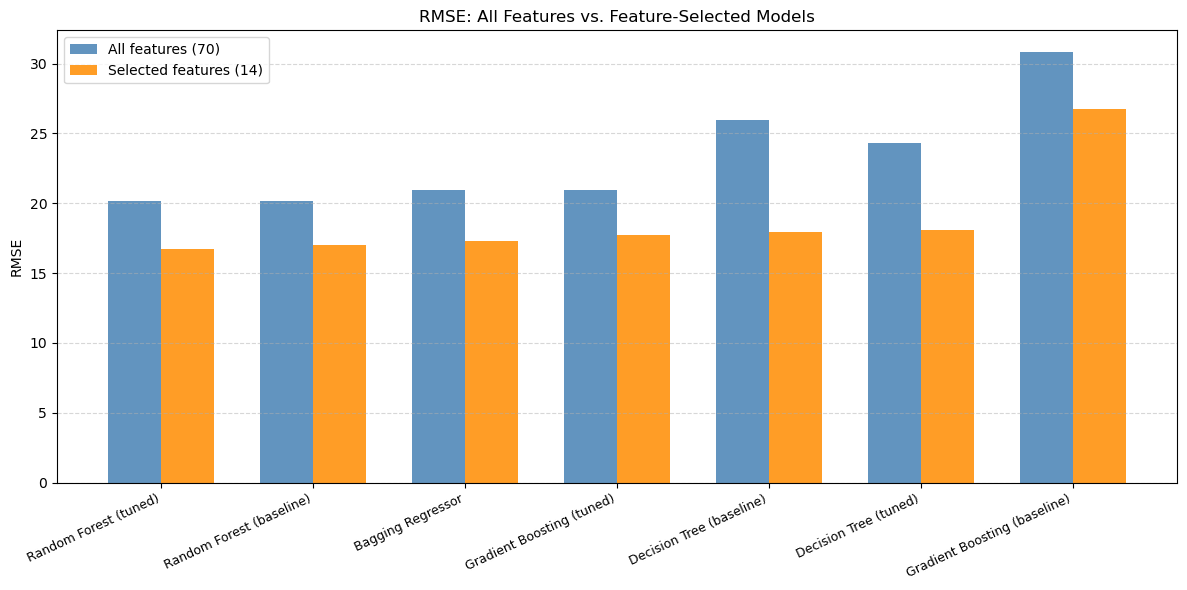

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison["RMSE (all feats)"], width,
               label="All features (70)", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, comparison["RMSE (selected)"],  width,
               label=f"Selected features ({len(selected_features)})",
               color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("RMSE")
ax.set_title("RMSE: All Features vs. Feature-Selected Models")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()